# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Load raw data

In [2]:
# Load raw data — keep train_raw untouched as the reference for index alignment
train_raw = pd.read_csv('raw_data/train.csv')
test_raw  = pd.read_csv('raw_data/test.csv')

print(f"Train shape : {train_raw.shape}")
print(f"Test shape  : {test_raw.shape}")

Train shape : (80000, 41)
Test shape  : (20000, 40)


# Preprocessing function

In [3]:
def preprocess(df_in, is_train=True):
    """
    Full preprocessing pipeline.
    Returns a clean DataFrame ready for modelling.
    The original index is preserved throughout so we can always
    join back metadata (age_bucket, training_program) later.
    """
    df = df_in.copy()

    # 1. Drop DNF rows (only in train — test has no target)
    if is_train:
        df = df.dropna(subset=['actual_finish_time_minutes'])

    # 2. Ordinal encoding
    df['training_program']  = df['training_program'].map({'Beginner': 1, 'Intermediate': 2, 'Advanced': 3})
    df['course_difficulty'] = df['course_difficulty'].map({'Flat': 1, 'Mixed': 2, 'Hilly': 3})
    df['injury_severity']   = df['injury_severity'].map({'Minor': 1, 'Moderate': 2, 'Severe': 3}).fillna(0)
    df['gender']            = df['gender'].map({'Male': 0, 'Female': 1, 'Non-binary': 2})

    # 3. One-hot encode marathon_weather
    weather_dummies = pd.get_dummies(df['marathon_weather'], prefix='weather', drop_first=True)
    df = pd.concat([df.drop(columns=['marathon_weather']), weather_dummies], axis=1)

    # 4. VO2 max imputation by age median
    df['vo2_max'] = df['vo2_max'].fillna(df.groupby('age')['vo2_max'].transform('median'))

    # 5. Fill remaining NaNs with column median
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    # 6. Drop columns that are leaky, duplicated, or uninformative
    drop_cols = [
        'runner_id', 'weekly_mileage_miles', 'target_finish_time_minutes',
        'medal_outcome', 'marathon_date', 'dnf', 'month', 'injury_severity_filled',
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df


train_clean = preprocess(train_raw, is_train=True)
test_clean  = preprocess(test_raw,  is_train=False)

print(f"Train clean shape : {train_clean.shape}")
print(f"Test clean shape  : {test_clean.shape}")
print(f"Columns           : {train_clean.columns.tolist()}")

Train clean shape : (78011, 40)
Test clean shape  : (20000, 40)
Columns           : ['age', 'gender', 'running_experience_months', 'previous_marathon_count', 'training_program', 'motivation_level', 'personal_best_minutes', 'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week', 'rest_days_per_week', 'training_adherence_pct', 'consecutive_weeks_no_miss', 'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score', 'hydration_consistency', 'training_streak_days', 'missed_workout_pct', 'early_morning_run_frequency', 'weather_condition_training_pct', 'goal_completion_rate', 'run_club_attendance_rate', 'warmup_adherence_pct', 'stretching_adherence_pct', 'course_difficulty', 'actual_finish_time_minutes', 'mental_preparation_score', 'weather_Cold', 'weather_Hot', 'weather_Rainy', 'weather_Sunny', 'weather_Windy']


# Age buckets

In [4]:
# Age buckets — kept in train_clean for subgroup analysis later
bins   = [18, 35, 45, 55, 100]
labels = ['18-34', '35-44', '45-54', '55+']
train_clean['age_bucket'] = pd.cut(train_clean['age'], bins=bins, labels=labels, right=False)

print(train_clean['age_bucket'].value_counts().sort_index())

age_bucket
18-34    27695
35-44    16303
45-54    16173
55+      17840
Name: count, dtype: int64


# Features and target (no PB)

In [5]:
# Drop age_bucket (metadata) and personal_best_minutes (handled separately in PB version)
X_no_pb = train_clean.drop(columns=['actual_finish_time_minutes', 'age_bucket', 'personal_best_minutes'])
y       = train_clean['actual_finish_time_minutes']

# Train/test split — X_train_no_pb and X_test_no_pb preserve the original index
X_train_no_pb, X_test_no_pb, y_train, y_test = train_test_split(
    X_no_pb, y, test_size=0.2, random_state=42
)

# Scale — fit on train only, transform both
# Convert back to DataFrame to keep column names after scaling
scaler_no_pb     = StandardScaler()
X_train_no_pb_sc = pd.DataFrame(scaler_no_pb.fit_transform(X_train_no_pb), columns=X_no_pb.columns)
X_test_no_pb_sc  = pd.DataFrame(scaler_no_pb.transform(X_test_no_pb),      columns=X_no_pb.columns)

print(f"Train : {X_train_no_pb_sc.shape} | Test : {X_test_no_pb_sc.shape}")

Train : (62408, 38) | Test : (15603, 38)


# Linear Regression baseline

In [6]:
lr = LinearRegression()
lr.fit(X_train_no_pb_sc, y_train)
y_pred_lr = lr.predict(X_test_no_pb_sc)

print("── Linear Regression (no PB) ────────────────────")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f} min")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f} min")
print(f"  R²   : {r2_score(y_test, y_pred_lr):.4f}")

── Linear Regression (no PB) ────────────────────
  RMSE : 20.21 min
  MAE  : 16.12 min
  R²   : 0.6350


# XGBoost default (no PB)

In [7]:
xgb_no_pb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_no_pb.fit(X_train_no_pb_sc, y_train,
              eval_set=[(X_test_no_pb_sc, y_test)], verbose=100)

y_pred_xgb_no_pb = xgb_no_pb.predict(X_test_no_pb_sc)

print("── XGBoost default (no PB) ──────────────────────")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb_no_pb)):.2f} min")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_xgb_no_pb):.2f} min")
print(f"  R²   : {r2_score(y_test, y_pred_xgb_no_pb):.4f}")

[0]	validation_0-rmse:274.94062
[100]	validation_0-rmse:20.15222
[200]	validation_0-rmse:20.07855
[300]	validation_0-rmse:20.09239
[400]	validation_0-rmse:20.11348
[499]	validation_0-rmse:20.13884
── XGBoost default (no PB) ──────────────────────
  RMSE : 20.14 min
  MAE  : 16.06 min
  R²   : 0.6375


# XGBoost RandomizedSearchCV (no PB)

In [8]:
param_grid = {
    'n_estimators':      [300, 500, 800],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
    'reg_alpha':         [0, 0.1, 1.0],
    'reg_lambda':        [1.0, 5.0],
}

search_no_pb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_no_pb.fit(X_train_no_pb_sc, y_train)

y_pred_tuned_no_pb = search_no_pb.best_estimator_.predict(X_test_no_pb_sc)

print("Best params:", search_no_pb.best_params_)
print(f"Best CV RMSE : {-search_no_pb.best_score_:.2f} min")
print("── XGBoost Tuned (no PB) ────────────────────────")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tuned_no_pb)):.2f} min")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_tuned_no_pb):.2f} min")
print(f"  R²   : {r2_score(y_test, y_pred_tuned_no_pb):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE : 20.11 min
── XGBoost Tuned (no PB) ────────────────────────
  RMSE : 20.08 min
  MAE  : 16.01 min
  R²   : 0.6396


# SHAP values (no PB)

In [9]:
# Compute SHAP values on the full feature test set
explainer_no_pb   = shap.TreeExplainer(search_no_pb.best_estimator_)
shap_values_no_pb = explainer_no_pb.shap_values(X_test_no_pb_sc)

# Average absolute SHAP per feature = mean impact in minutes on predicted finish time
shap_imp_no_pb = pd.Series(
    np.abs(shap_values_no_pb).mean(axis=0),
    index=X_no_pb.columns
).sort_values(ascending=False)

print(shap_imp_no_pb.to_string())

running_experience_months         17.220778
training_program                   4.763477
injury_severity                    3.635836
course_difficulty                  2.898415
injury_count                       2.377539
weather_Hot                        1.704791
resting_heart_rate_bpm             1.644408
weather_Rainy                      0.982622
recovery_score                     0.836834
weather_Windy                      0.820618
missed_workout_pct                 0.733165
weekly_mileage_km                  0.724650
vo2_max                            0.721638
weather_Cold                       0.686292
nutrition_score                    0.652848
run_club_attendance_rate           0.577616
weather_Sunny                      0.503172
goal_completion_rate               0.423481
mental_preparation_score           0.420289
age                                0.334360
speed_work_sessions_per_week       0.319862
motivation_level                   0.267737
runs_per_week                   

# SHAP feature selection and retrain (no PB)


In [10]:
# Drop features whose average SHAP impact is below 0.5 minutes
shap_threshold  = 1
weak_shap_no_pb = shap_imp_no_pb[shap_imp_no_pb < shap_threshold].index.tolist()

print(f"Dropping {len(weak_shap_no_pb)} weak features: {weak_shap_no_pb}")
print(f"Keeping  {len(shap_imp_no_pb) - len(weak_shap_no_pb)} features")

X_train_shap_no_pb = X_train_no_pb_sc.drop(columns=weak_shap_no_pb)
X_test_shap_no_pb  = X_test_no_pb_sc.drop(columns=weak_shap_no_pb)

model_shap_no_pb  = XGBRegressor(**search_no_pb.best_params_, random_state=42, n_jobs=-1)
model_shap_no_pb.fit(X_train_shap_no_pb, y_train)
y_pred_shap_no_pb = model_shap_no_pb.predict(X_test_shap_no_pb)

print(f"── XGBoost SHAP Selection (no PB) ───────────────")
print(f"  Features : {X_train_shap_no_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_shap_no_pb)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred_shap_no_pb):.2f} min")
print(f"  R²       : {r2_score(y_test, y_pred_shap_no_pb):.4f}")

Dropping 31 weak features: ['weather_Rainy', 'recovery_score', 'weather_Windy', 'missed_workout_pct', 'weekly_mileage_km', 'vo2_max', 'weather_Cold', 'nutrition_score', 'run_club_attendance_rate', 'weather_Sunny', 'goal_completion_rate', 'mental_preparation_score', 'age', 'speed_work_sessions_per_week', 'motivation_level', 'runs_per_week', 'training_adherence_pct', 'bmi', 'hydration_consistency', 'warmup_adherence_pct', 'long_run_distance_km', 'stretching_adherence_pct', 'sleep_hours_avg', 'cross_training_hours_per_week', 'early_morning_run_frequency', 'training_streak_days', 'weather_condition_training_pct', 'consecutive_weeks_no_miss', 'previous_marathon_count', 'gender', 'rest_days_per_week']
Keeping  7 features
── XGBoost SHAP Selection (no PB) ───────────────
  Features : 7
  RMSE     : 20.48 min
  MAE      : 16.35 min
  R²       : 0.6250


# SHAP XGBoost RandomizedSearchCV (no PB)¶

In [11]:
search_shap_no_pb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_shap_no_pb.fit(X_train_shap_no_pb, y_train)

y_pred_shap_no_pb_tuned = search_shap_no_pb.best_estimator_.predict(X_test_shap_no_pb)

print("Best params:", search_shap_no_pb.best_params_)
print(f"Best CV RMSE : {-search_shap_no_pb.best_score_:.2f} min")
print(f"── XGBoost SHAP Tuned (no PB) ───────────────────")
print(f"  Features : {X_train_shap_no_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_shap_no_pb_tuned)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred_shap_no_pb_tuned):.2f} min")
print(f"  R²       : {r2_score(y_test, y_pred_shap_no_pb_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV RMSE : 20.52 min
── XGBoost SHAP Tuned (no PB) ───────────────────
  Features : 7
  RMSE     : 20.47 min
  MAE      : 16.35 min
  R²       : 0.6255


# SHAP plots (no PB)

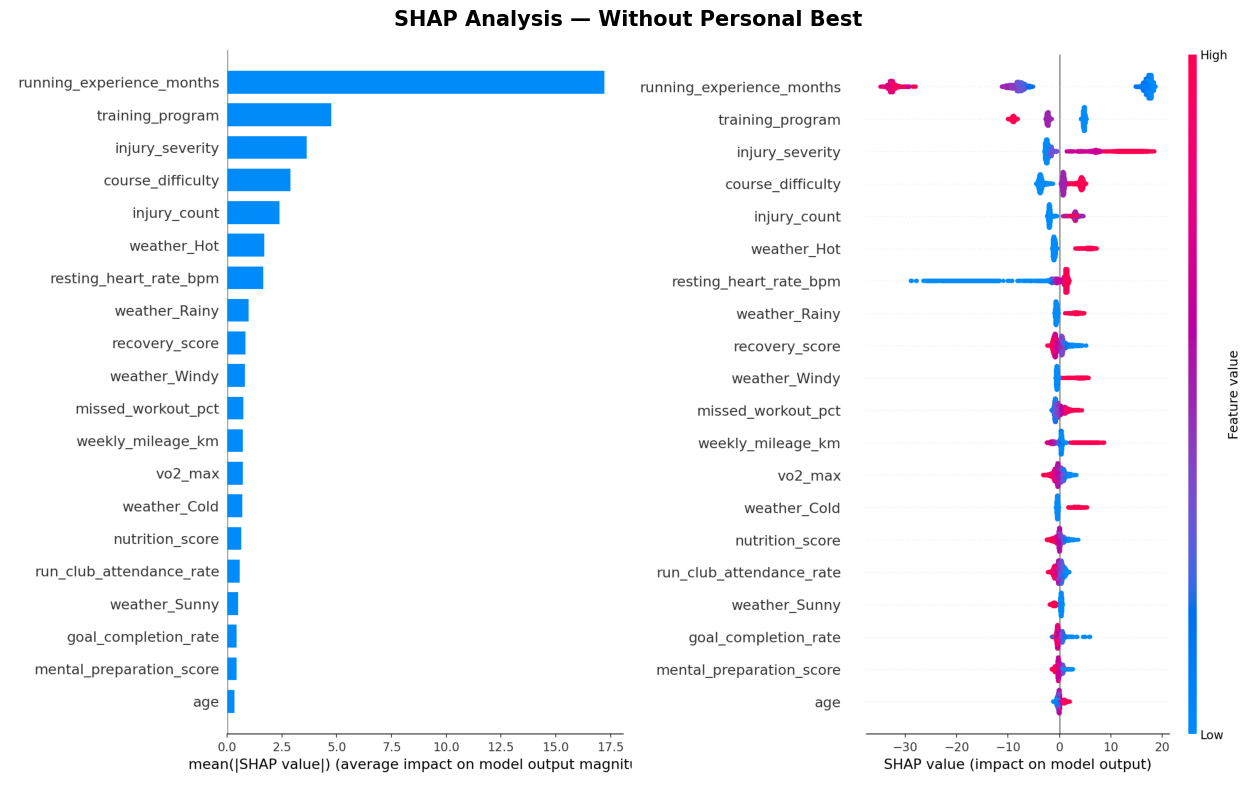

In [13]:

import io
from PIL import Image

def shap_to_image(shap_values, X, plot_type='bar'):
    """Render a SHAP plot to a PIL image without displaying it."""
    if plot_type == 'beeswarm':
        # beeswarm needs plot_type omitted entirely
        shap.summary_plot(shap_values, X, show=False)
    else:
        shap.summary_plot(shap_values, X, plot_type=plot_type, show=False)
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    plt.close()
    buf.seek(0)
    return Image.open(buf)

# Render each plot independently
img_bar      = shap_to_image(shap_values_no_pb, X_test_no_pb_sc, plot_type='bar')
img_beeswarm = shap_to_image(shap_values_no_pb, X_test_no_pb_sc, plot_type='beeswarm')

# Combine side by side
total_width  = img_bar.width + img_beeswarm.width
total_height = max(img_bar.height, img_beeswarm.height)
combined     = Image.new('RGB', (total_width, total_height), 'white')
combined.paste(img_bar,      (0, 0))
combined.paste(img_beeswarm, (img_bar.width, 0))

# Display
fig, ax = plt.subplots(figsize=(22, 8))
ax.imshow(combined)
ax.axis('off')
ax.set_title("SHAP Analysis — Without Personal Best", fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Adding PB 

# Features and target (with PB)

In [17]:
# Add personal_best_minutes from train_raw aligned by index
# Fill NaN (first-time marathoners) with median
X_pb = train_clean.drop(columns=['actual_finish_time_minutes', 'age_bucket'])
X_pb['personal_best_minutes'] = train_raw.loc[train_clean.index, 'personal_best_minutes']
X_pb['personal_best_minutes'] = X_pb['personal_best_minutes'].fillna(X_pb['personal_best_minutes'].median())

X_train_pb, X_test_pb, y_train_pb, y_test_pb = train_test_split(
    X_pb, y, test_size=0.2, random_state=42
)

scaler_pb     = StandardScaler()
X_train_pb_sc = pd.DataFrame(scaler_pb.fit_transform(X_train_pb), columns=X_pb.columns)
X_test_pb_sc  = pd.DataFrame(scaler_pb.transform(X_test_pb),      columns=X_pb.columns)

print(f"Train : {X_train_pb_sc.shape} | Test : {X_test_pb_sc.shape}")

Train : (62408, 39) | Test : (15603, 39)


# XGBoost RandomizedSearchCV (with PB)

In [18]:
search_pb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_pb.fit(X_train_pb_sc, y_train_pb)

y_pred_tuned_pb = search_pb.best_estimator_.predict(X_test_pb_sc)

print("Best params:", search_pb.best_params_)
print(f"Best CV RMSE : {-search_pb.best_score_:.2f} min")
print("── XGBoost Tuned (with PB) ──────────────────────")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test_pb, y_pred_tuned_pb)):.2f} min")
print(f"  MAE  : {mean_absolute_error(y_test_pb, y_pred_tuned_pb):.2f} min")
print(f"  R²   : {r2_score(y_test_pb, y_pred_tuned_pb):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV RMSE : 13.65 min
── XGBoost Tuned (with PB) ──────────────────────
  RMSE : 13.37 min
  MAE  : 10.49 min
  R²   : 0.8403


# SHAP values (with PB)

In [19]:
explainer_pb   = shap.TreeExplainer(search_pb.best_estimator_)
shap_values_pb = explainer_pb.shap_values(X_test_pb_sc)

shap_imp_pb = pd.Series(
    np.abs(shap_values_pb).mean(axis=0),
    index=X_pb.columns
).sort_values(ascending=False)

print(shap_imp_pb.to_string())

running_experience_months         14.093815
personal_best_minutes             12.624001
injury_severity                    3.601079
course_difficulty                  2.925751
injury_count                       2.500263
weather_Hot                        1.651212
resting_heart_rate_bpm             1.453946
weather_Rainy                      1.029663
vo2_max                            0.949391
weather_Windy                      0.868036
recovery_score                     0.843381
weather_Cold                       0.738215
training_program                   0.715196
missed_workout_pct                 0.682656
weekly_mileage_km                  0.663374
run_club_attendance_rate           0.624293
previous_marathon_count            0.606860
nutrition_score                    0.581750
training_adherence_pct             0.466000
age                                0.426668
mental_preparation_score           0.386803
goal_completion_rate               0.356356
weather_Sunny                   

# SHAP feature selection and retrain (with PB)

In [20]:
weak_shap_pb = shap_imp_pb[shap_imp_pb < shap_threshold].index.tolist()

print(f"Dropping {len(weak_shap_pb)} weak features: {weak_shap_pb}")
print(f"Keeping  {len(shap_imp_pb) - len(weak_shap_pb)} features")

X_train_shap_pb = X_train_pb_sc.drop(columns=weak_shap_pb)
X_test_shap_pb  = X_test_pb_sc.drop(columns=weak_shap_pb)

model_shap_pb  = XGBRegressor(**search_pb.best_params_, random_state=42, n_jobs=-1)
model_shap_pb.fit(X_train_shap_pb, y_train_pb)
y_pred_shap_pb = model_shap_pb.predict(X_test_shap_pb)

print(f"── XGBoost SHAP Selection (with PB) ─────────────")
print(f"  Features : {X_train_shap_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test_pb, y_pred_shap_pb)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test_pb, y_pred_shap_pb):.2f} min")
print(f"  R²       : {r2_score(y_test_pb, y_pred_shap_pb):.4f}")

Dropping 31 weak features: ['vo2_max', 'weather_Windy', 'recovery_score', 'weather_Cold', 'training_program', 'missed_workout_pct', 'weekly_mileage_km', 'run_club_attendance_rate', 'previous_marathon_count', 'nutrition_score', 'training_adherence_pct', 'age', 'mental_preparation_score', 'goal_completion_rate', 'weather_Sunny', 'long_run_distance_km', 'bmi', 'motivation_level', 'stretching_adherence_pct', 'training_streak_days', 'cross_training_hours_per_week', 'warmup_adherence_pct', 'sleep_hours_avg', 'weather_condition_training_pct', 'hydration_consistency', 'early_morning_run_frequency', 'consecutive_weeks_no_miss', 'speed_work_sessions_per_week', 'gender', 'runs_per_week', 'rest_days_per_week']
Keeping  8 features
── XGBoost SHAP Selection (with PB) ─────────────
  Features : 8
  RMSE     : 13.99 min
  MAE      : 10.98 min
  R²       : 0.8251


# SHAP plots (with PB)


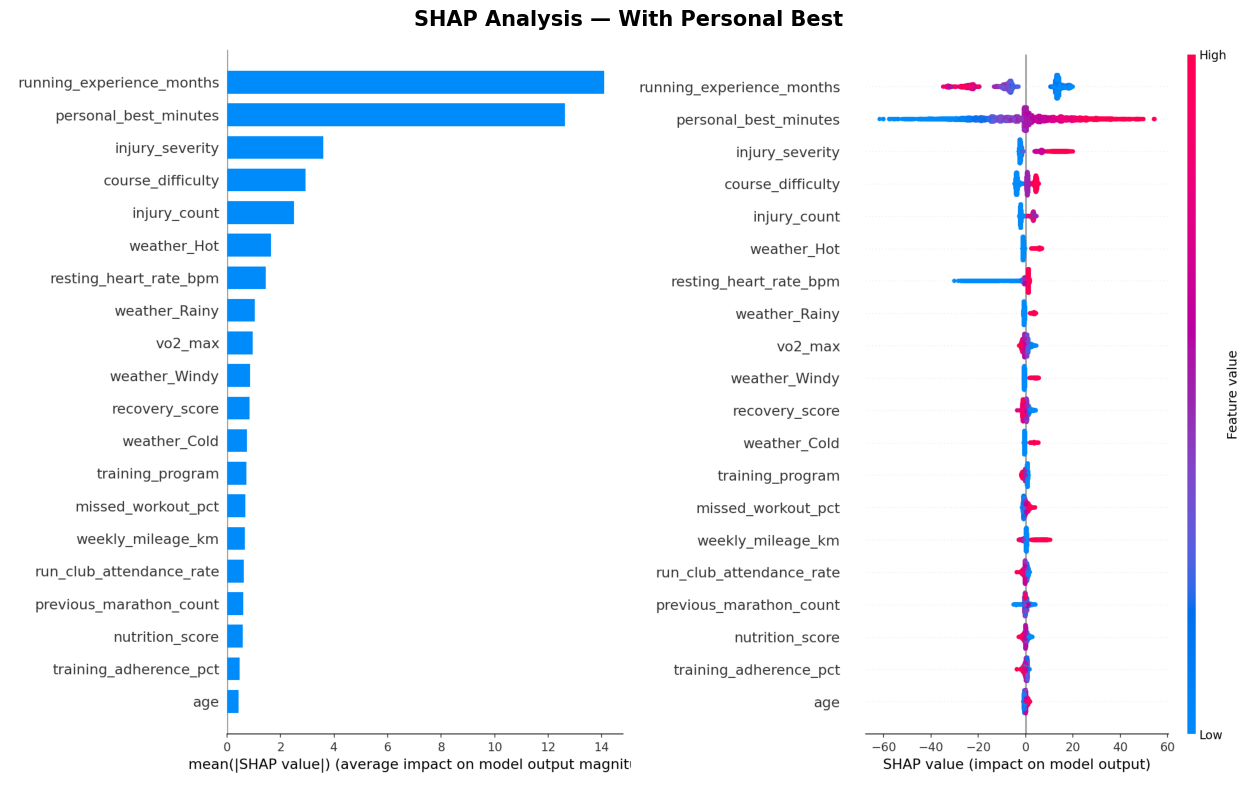

In [21]:
img_bar      = shap_to_image(shap_values_pb, X_test_pb_sc, plot_type='bar')
img_beeswarm = shap_to_image(shap_values_pb, X_test_pb_sc, plot_type='beeswarm')

total_width  = img_bar.width + img_beeswarm.width
total_height = max(img_bar.height, img_beeswarm.height)
combined     = Image.new('RGB', (total_width, total_height), 'white')
combined.paste(img_bar,      (0, 0))
combined.paste(img_beeswarm, (img_bar.width, 0))

fig, ax = plt.subplots(figsize=(22, 8))
ax.imshow(combined)
ax.axis('off')
ax.set_title("SHAP Analysis — With Personal Best", fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# RandomizedSearchCV on SHAP-selected features (with PB)

In [22]:
search_shap_pb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_shap_pb.fit(X_train_shap_pb, y_train_pb)

y_pred_shap_pb_tuned = search_shap_pb.best_estimator_.predict(X_test_shap_pb)

print("Best params:", search_shap_pb.best_params_)
print(f"Best CV RMSE : {-search_shap_pb.best_score_:.2f} min")
print("── XGBoost SHAP Selection Tuned (with PB) ───────")
print(f"  Features : {X_train_shap_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test_pb, y_pred_shap_pb_tuned)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test_pb, y_pred_shap_pb_tuned):.2f} min")
print(f"  R²       : {r2_score(y_test_pb, y_pred_shap_pb_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV RMSE : 14.26 min
── XGBoost SHAP Selection Tuned (with PB) ───────
  Features : 8
  RMSE     : 14.00 min
  MAE      : 10.99 min
  R²       : 0.8247


# No injury features model (with PB)

In [23]:
# Remove injury_severity and injury_count from the SHAP-selected features
# to test whether the model holds up without injury data
injury_cols = ['injury_severity', 'injury_count']

X_train_no_inj = X_train_shap_pb.drop(columns=[c for c in injury_cols if c in X_train_shap_pb.columns])
X_test_no_inj  = X_test_shap_pb.drop(columns=[c for c in injury_cols if c in X_test_shap_pb.columns])

print(f"Features kept : {X_train_no_inj.shape[1]}")
print(f"Dropped       : {[c for c in injury_cols if c in X_train_shap_pb.columns]}")
print(f"Remaining     : {X_train_no_inj.columns.tolist()}")

Features kept : 6
Dropped       : ['injury_severity', 'injury_count']
Remaining     : ['running_experience_months', 'personal_best_minutes', 'resting_heart_rate_bpm', 'course_difficulty', 'weather_Hot', 'weather_Rainy']


# Retrain on no-injury features

In [24]:
model_no_inj  = XGBRegressor(**search_shap_pb.best_params_, random_state=42, n_jobs=-1)
model_no_inj.fit(X_train_no_inj, y_train_pb)
y_pred_no_inj = model_no_inj.predict(X_test_no_inj)

print(f"── XGBoost SHAP + No Injury Features (with PB) ──")
print(f"  Features : {X_train_no_inj.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test_pb, y_pred_no_inj)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test_pb, y_pred_no_inj):.2f} min")
print(f"  R²       : {r2_score(y_test_pb, y_pred_no_inj):.4f}")

── XGBoost SHAP + No Injury Features (with PB) ──
  Features : 6
  RMSE     : 15.67 min
  MAE      : 12.32 min
  R²       : 0.7805


# Tune the no-injury model

In [25]:
search_no_inj = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_no_inj.fit(X_train_no_inj, y_train_pb)

y_pred_no_inj_tuned = search_no_inj.best_estimator_.predict(X_test_no_inj)

print("Best params:", search_no_inj.best_params_)
print(f"Best CV RMSE : {-search_no_inj.best_score_:.2f} min")
print(f"── XGBoost SHAP + No Injury Tuned (with PB) ─────")
print(f"  Features : {X_train_no_inj.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test_pb, y_pred_no_inj_tuned)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test_pb, y_pred_no_inj_tuned):.2f} min")
print(f"  R²       : {r2_score(y_test_pb, y_pred_no_inj_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV RMSE : 15.79 min
── XGBoost SHAP + No Injury Tuned (with PB) ─────
  Features : 6
  RMSE     : 15.68 min
  MAE      : 12.33 min
  R²       : 0.7802


# SHAP plots for no-injury model

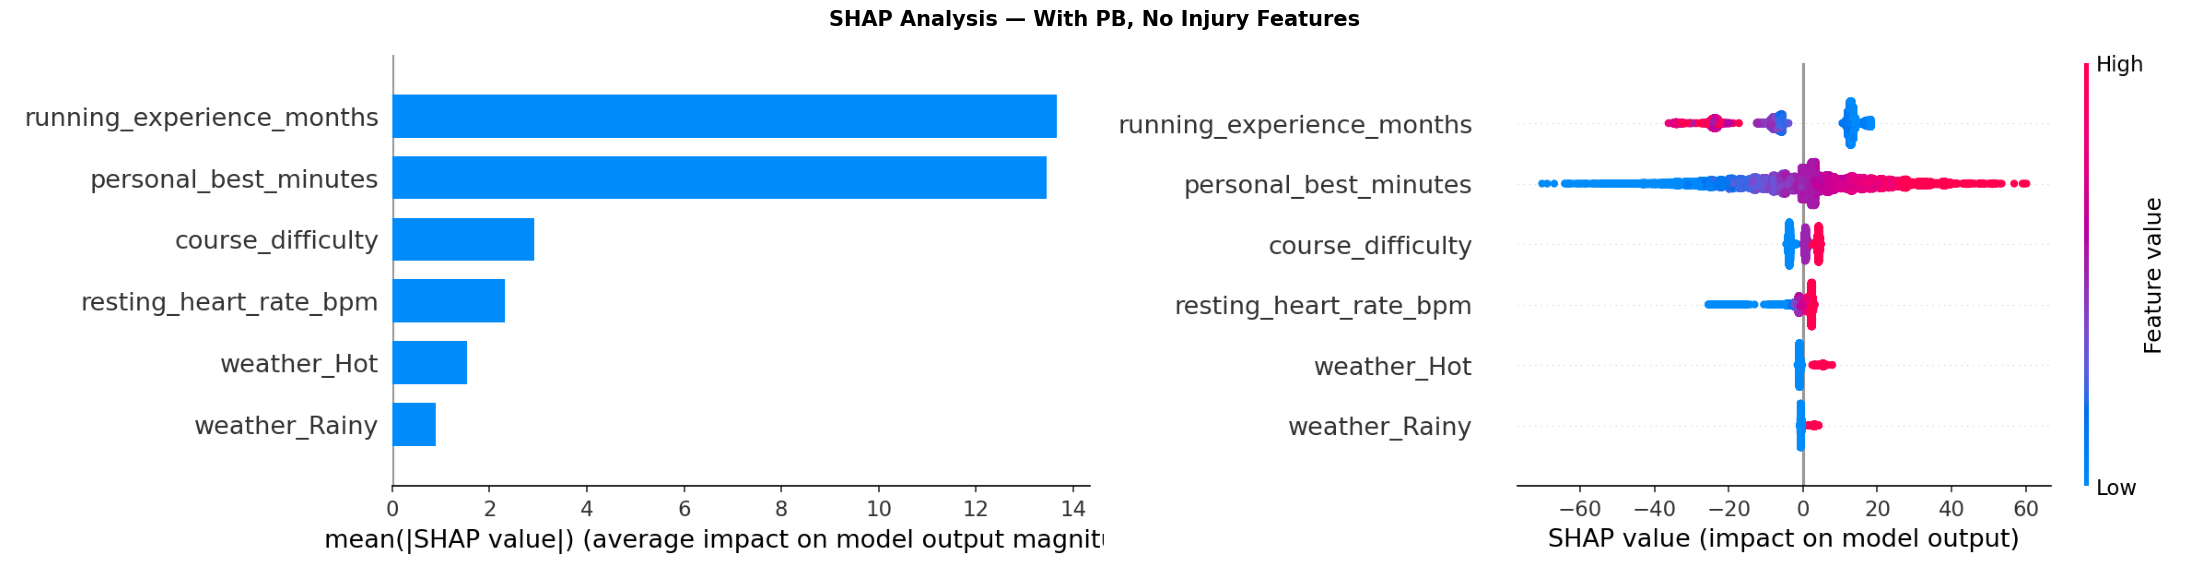

In [26]:
explainer_no_inj   = shap.TreeExplainer(search_no_inj.best_estimator_)
shap_values_no_inj = explainer_no_inj.shap_values(X_test_no_inj)

img_bar      = shap_to_image(shap_values_no_inj, X_test_no_inj, plot_type='bar')
img_beeswarm = shap_to_image(shap_values_no_inj, X_test_no_inj, plot_type='beeswarm')

total_width  = img_bar.width + img_beeswarm.width
total_height = max(img_bar.height, img_beeswarm.height)
combined     = Image.new('RGB', (total_width, total_height), 'white')
combined.paste(img_bar,      (0, 0))
combined.paste(img_beeswarm, (img_bar.width, 0))

fig, ax = plt.subplots(figsize=(22, 8))
ax.imshow(combined)
ax.axis('off')
ax.set_title("SHAP Analysis — With PB, No Injury Features", fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# SHAP selection no injury no PB

In [27]:
# Remove injury_severity and injury_count from the no PB SHAP-selected features
injury_cols = ['injury_severity', 'injury_count']

X_train_no_inj_no_pb = X_train_shap_no_pb.drop(columns=[c for c in injury_cols if c in X_train_shap_no_pb.columns])
X_test_no_inj_no_pb  = X_test_shap_no_pb.drop(columns=[c for c in injury_cols if c in X_test_shap_no_pb.columns])

print(f"Features kept : {X_train_no_inj_no_pb.shape[1]}")
print(f"Dropped       : {[c for c in injury_cols if c in X_train_shap_no_pb.columns]}")
print(f"Remaining     : {X_train_no_inj_no_pb.columns.tolist()}")

Features kept : 5
Dropped       : ['injury_severity', 'injury_count']
Remaining     : ['running_experience_months', 'training_program', 'resting_heart_rate_bpm', 'course_difficulty', 'weather_Hot']


#  SHAP selection no injury no PB Retrain (not tuned)

In [28]:
model_no_inj_no_pb  = XGBRegressor(**search_shap_no_pb.best_params_, random_state=42, n_jobs=-1)
model_no_inj_no_pb.fit(X_train_no_inj_no_pb, y_train)
y_pred_no_inj_no_pb = model_no_inj_no_pb.predict(X_test_no_inj_no_pb)

print(f"── XGBoost SHAP No Injury (no PB) ───────────────")
print(f"  Features : {X_train_no_inj_no_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_no_inj_no_pb)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred_no_inj_no_pb):.2f} min")
print(f"  R²       : {r2_score(y_test, y_pred_no_inj_no_pb):.4f}")

── XGBoost SHAP No Injury (no PB) ───────────────
  Features : 5
  RMSE     : 21.60 min
  MAE      : 17.25 min
  R²       : 0.5832


# SHAP selection no injury no PB Retrain TUNED

In [29]:
search_no_inj_no_pb = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, tree_method='hist'),
    param_distributions=param_grid,
    n_iter=50, scoring='neg_root_mean_squared_error',
    cv=5, refit=True, random_state=42, verbose=1,
)

search_no_inj_no_pb.fit(X_train_no_inj_no_pb, y_train)

y_pred_no_inj_no_pb_tuned = search_no_inj_no_pb.best_estimator_.predict(X_test_no_inj_no_pb)

print("Best params:", search_no_inj_no_pb.best_params_)
print(f"Best CV RMSE : {-search_no_inj_no_pb.best_score_:.2f} min")
print(f"── XGBoost SHAP No Injury Tuned (no PB) ─────────")
print(f"  Features : {X_train_no_inj_no_pb.shape[1]}")
print(f"  RMSE     : {np.sqrt(mean_squared_error(y_test, y_pred_no_inj_no_pb_tuned)):.2f} min")
print(f"  MAE      : {mean_absolute_error(y_test, y_pred_no_inj_no_pb_tuned):.2f} min")
print(f"  R²       : {r2_score(y_test, y_pred_no_inj_no_pb_tuned):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV RMSE : 21.60 min
── XGBoost SHAP No Injury Tuned (no PB) ─────────
  Features : 5
  RMSE     : 21.60 min
  MAE      : 17.25 min
  R²       : 0.5831


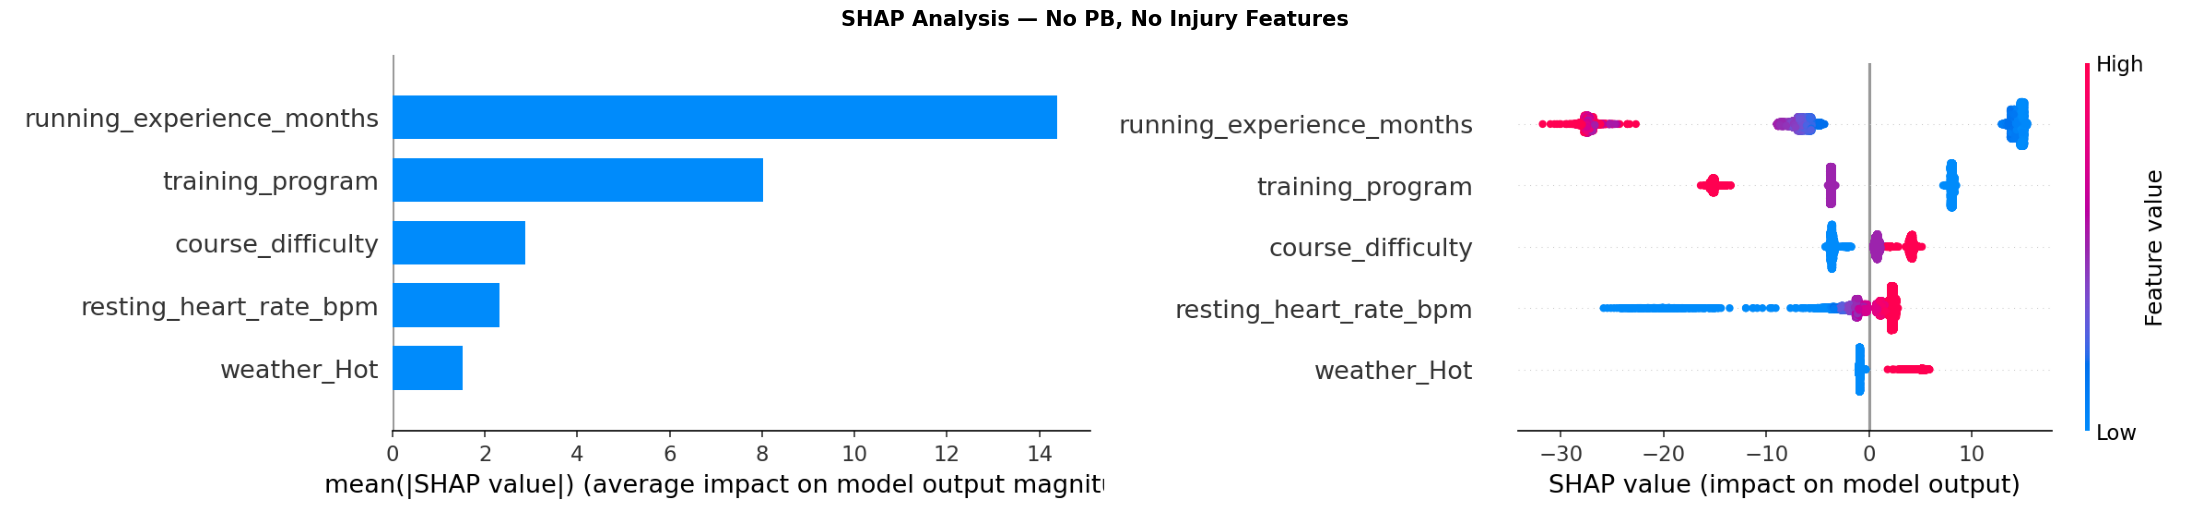

In [30]:
explainer_no_inj_no_pb   = shap.TreeExplainer(search_no_inj_no_pb.best_estimator_)
shap_values_no_inj_no_pb = explainer_no_inj_no_pb.shap_values(X_test_no_inj_no_pb)

img_bar      = shap_to_image(shap_values_no_inj_no_pb, X_test_no_inj_no_pb, plot_type='bar')
img_beeswarm = shap_to_image(shap_values_no_inj_no_pb, X_test_no_inj_no_pb, plot_type='beeswarm')

total_width  = img_bar.width + img_beeswarm.width
total_height = max(img_bar.height, img_beeswarm.height)
combined     = Image.new('RGB', (total_width, total_height), 'white')
combined.paste(img_bar,      (0, 0))
combined.paste(img_beeswarm, (img_bar.width, 0))

fig, ax = plt.subplots(figsize=(22, 8))
ax.imshow(combined)
ax.axis('off')
ax.set_title("SHAP Analysis — No PB, No Injury Features", fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Summary

In [31]:
rows = []

rows.append({'Model': 'Linear Regression (no PB)',              'Features': X_train_no_pb_sc.shape[1],   'RMSE': np.sqrt(mean_squared_error(y_test,    y_pred_lr)),                    'MAE': mean_absolute_error(y_test,    y_pred_lr),                    'R2': r2_score(y_test,    y_pred_lr)})
rows.append({'Model': 'XGBoost default (no PB)',                'Features': X_train_no_pb_sc.shape[1],   'RMSE': np.sqrt(mean_squared_error(y_test,    y_pred_xgb_no_pb)),              'MAE': mean_absolute_error(y_test,    y_pred_xgb_no_pb),              'R2': r2_score(y_test,    y_pred_xgb_no_pb)})
rows.append({'Model': 'XGBoost Tuned (no PB)',                  'Features': X_train_no_pb_sc.shape[1],   'RMSE': np.sqrt(mean_squared_error(y_test,    y_pred_tuned_no_pb)),            'MAE': mean_absolute_error(y_test,    y_pred_tuned_no_pb),            'R2': r2_score(y_test,    y_pred_tuned_no_pb)})
rows.append({'Model': 'XGBoost SHAP Selection (no PB)',         'Features': X_train_shap_no_pb.shape[1], 'RMSE': np.sqrt(mean_squared_error(y_test,    y_pred_shap_no_pb)),             'MAE': mean_absolute_error(y_test,    y_pred_shap_no_pb),             'R2': r2_score(y_test,    y_pred_shap_no_pb)})
rows.append({'Model': 'XGBoost SHAP Tuned (no PB)',             'Features': X_train_shap_no_pb.shape[1], 'RMSE': np.sqrt(mean_squared_error(y_test,    y_pred_shap_no_pb_tuned)),      'MAE': mean_absolute_error(y_test,    y_pred_shap_no_pb_tuned),      'R2': r2_score(y_test,    y_pred_shap_no_pb_tuned)})
rows.append({'Model': 'XGBoost Tuned (with PB)',                'Features': X_train_pb_sc.shape[1],      'RMSE': np.sqrt(mean_squared_error(y_test_pb, y_pred_tuned_pb)),              'MAE': mean_absolute_error(y_test_pb, y_pred_tuned_pb),              'R2': r2_score(y_test_pb, y_pred_tuned_pb)})
rows.append({'Model': 'XGBoost SHAP Selection (with PB)',       'Features': X_train_shap_pb.shape[1],    'RMSE': np.sqrt(mean_squared_error(y_test_pb, y_pred_shap_pb)),               'MAE': mean_absolute_error(y_test_pb, y_pred_shap_pb),               'R2': r2_score(y_test_pb, y_pred_shap_pb)})
rows.append({'Model': 'XGBoost SHAP Tuned (with PB)',           'Features': X_train_shap_pb.shape[1],    'RMSE': np.sqrt(mean_squared_error(y_test_pb, y_pred_shap_pb_tuned)),        'MAE': mean_absolute_error(y_test_pb, y_pred_shap_pb_tuned),        'R2': r2_score(y_test_pb, y_pred_shap_pb_tuned)})
rows.append({'Model': 'XGBoost SHAP No Injury (with PB)',       'Features': X_train_no_inj.shape[1],     'RMSE': np.sqrt(mean_squared_error(y_test_pb, y_pred_no_inj)),                'MAE': mean_absolute_error(y_test_pb, y_pred_no_inj),                'R2': r2_score(y_test_pb, y_pred_no_inj)})
rows.append({'Model': 'XGBoost SHAP No Injury Tuned (with PB)', 'Features': X_train_no_inj.shape[1],    'RMSE': np.sqrt(mean_squared_error(y_test_pb, y_pred_no_inj_tuned)),         'MAE': mean_absolute_error(y_test_pb, y_pred_no_inj_tuned),         'R2': r2_score(y_test_pb, y_pred_no_inj_tuned)})
rows.append({'Model': 'XGBoost SHAP No Injury (no PB)',       'Features': X_train_no_inj_no_pb.shape[1], 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_no_inj_no_pb)),       'MAE': mean_absolute_error(y_test, y_pred_no_inj_no_pb),       'R2': r2_score(y_test, y_pred_no_inj_no_pb)})
rows.append({'Model': 'XGBoost SHAP No Injury Tuned (no PB)', 'Features': X_train_no_inj_no_pb.shape[1], 'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_no_inj_no_pb_tuned)), 'MAE': mean_absolute_error(y_test, y_pred_no_inj_no_pb_tuned), 'R2': r2_score(y_test, y_pred_no_inj_no_pb_tuned)})
summary = pd.DataFrame(rows)
summary['RMSE'] = summary['RMSE'].round(2)
summary['MAE']  = summary['MAE'].round(2)
summary['R2']   = summary['R2'].round(4)

print(summary.to_string(index=False))

                                 Model  Features  RMSE   MAE     R2
             Linear Regression (no PB)        38 20.21 16.12 0.6350
               XGBoost default (no PB)        38 20.14 16.06 0.6375
                 XGBoost Tuned (no PB)        38 20.08 16.01 0.6396
        XGBoost SHAP Selection (no PB)         7 20.48 16.35 0.6250
            XGBoost SHAP Tuned (no PB)         7 20.47 16.35 0.6255
               XGBoost Tuned (with PB)        39 13.37 10.49 0.8403
      XGBoost SHAP Selection (with PB)         8 13.99 10.98 0.8251
          XGBoost SHAP Tuned (with PB)         8 14.00 10.99 0.8247
      XGBoost SHAP No Injury (with PB)         6 15.67 12.32 0.7805
XGBoost SHAP No Injury Tuned (with PB)         6 15.68 12.33 0.7802
        XGBoost SHAP No Injury (no PB)         5 21.60 17.25 0.5832
  XGBoost SHAP No Injury Tuned (no PB)         5 21.60 17.25 0.5831


In [32]:
models_features = {
    'XGBoost SHAP Selection (no PB)'            : X_train_shap_no_pb.columns.tolist(),
    'XGBoost SHAP Tuned (no PB)'                : X_train_shap_no_pb.columns.tolist(),
    'XGBoost SHAP No Injury (no PB)'            : X_train_no_inj_no_pb.columns.tolist(),
    'XGBoost SHAP No Injury Tuned (no PB)'      : X_train_no_inj_no_pb.columns.tolist(),
    'XGBoost SHAP Selection (with PB)'          : X_train_shap_pb.columns.tolist(),
    'XGBoost SHAP Tuned (with PB)'              : X_train_shap_pb.columns.tolist(),
    'XGBoost SHAP No Injury (with PB)'          : X_train_no_inj.columns.tolist(),
    'XGBoost SHAP No Injury Tuned (with PB)'    : X_train_no_inj.columns.tolist(),
}

for model_name, features in models_features.items():
    print(f"\n── {model_name} ({len(features)} features) ──────────────────")
    for i, feat in enumerate(features, 1):
        print(f"  {i:02d}. {feat}")


── XGBoost SHAP Selection (no PB) (7 features) ──────────────────
  01. running_experience_months
  02. training_program
  03. resting_heart_rate_bpm
  04. injury_count
  05. injury_severity
  06. course_difficulty
  07. weather_Hot

── XGBoost SHAP Tuned (no PB) (7 features) ──────────────────
  01. running_experience_months
  02. training_program
  03. resting_heart_rate_bpm
  04. injury_count
  05. injury_severity
  06. course_difficulty
  07. weather_Hot

── XGBoost SHAP No Injury (no PB) (5 features) ──────────────────
  01. running_experience_months
  02. training_program
  03. resting_heart_rate_bpm
  04. course_difficulty
  05. weather_Hot

── XGBoost SHAP No Injury Tuned (no PB) (5 features) ──────────────────
  01. running_experience_months
  02. training_program
  03. resting_heart_rate_bpm
  04. course_difficulty
  05. weather_Hot

── XGBoost SHAP Selection (with PB) (8 features) ──────────────────
  01. running_experience_months
  02. personal_best_minutes
  03. resting_h